In [1]:
import platform
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device (wie im Trainings-Notebook)
if platform.system() == "Darwin":
    device = torch.device("mps" if torch.backends.mps.is_built() else "cpu")
else:
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# Config (nur was für die Evaluierung gebraucht wird)
DATA_DIR    = Path("../data/split")
IMG_SIZE    = 128
BATCH_SIZE  = 32
NUM_WORKERS = 0
NUM_CLASSES = 10
DROPOUT     = 0.5
BEST_PATH   = "../models/best_run13.pt"

mps


In [2]:
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_set    = datasets.ImageFolder(DATA_DIR / "test", transform=eval_transform)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Testbilder:", len(test_set))
print("Klassen:", test_set.classes)

Testbilder: 381
Klassen: ['alternative_rock', 'classical', 'country', 'hiphop', 'house', 'indie_rock', 'jazz', 'metal', 'reggae', 'techno']


In [3]:
class CoverCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(kernel_size=2, stride=2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1     = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(dropout)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
model = CoverCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(device)
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
model.eval()

class_names = test_set.classes

test_acc       = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES).to(device)
test_acc_class = torchmetrics.Accuracy(task="multiclass", num_classes=NUM_CLASSES, average=None).to(device)
confmat        = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES).to(device)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        pred = model(images)
        test_acc.update(pred, labels)
        test_acc_class.update(pred, labels)
        confmat.update(pred, labels)

overall   = test_acc.compute().item()
per_class = test_acc_class.compute().cpu().numpy()
cm        = confmat.compute().cpu().numpy()

print(f"Gesamt-Accuracy (Test): {overall:.4f}\n")
print("Accuracy pro Klasse (sortiert):")
for name, acc in sorted(zip(class_names, per_class), key=lambda t: t[1], reverse=True):
    print(f"  {name:18s} {acc:.3f}")

Gesamt-Accuracy (Test): 0.2598

Accuracy pro Klasse (sortiert):
  metal              0.512
  reggae             0.378
  hiphop             0.343
  classical          0.323
  techno             0.222
  country            0.212
  jazz               0.195
  house              0.171
  indie_rock         0.154
  alternative_rock   0.105


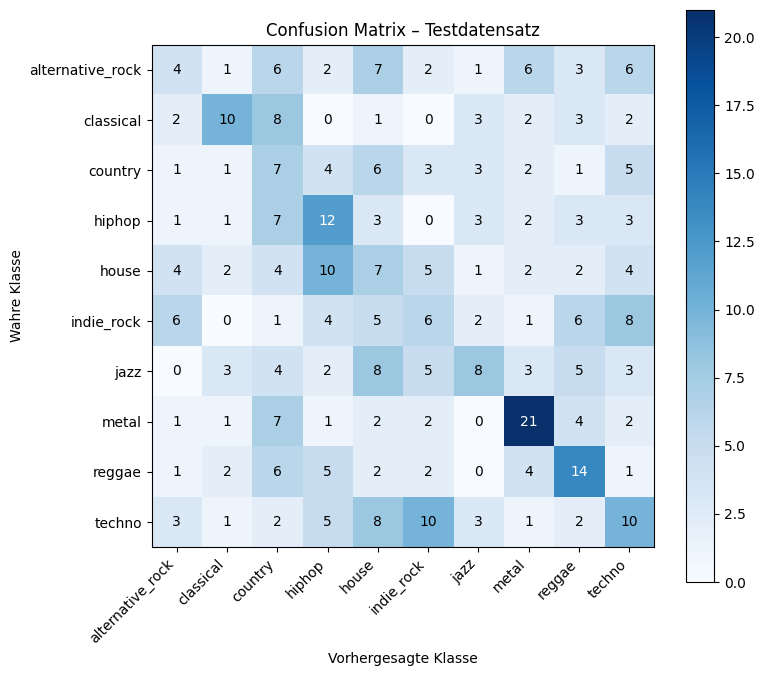

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Vorhergesagte Klasse"); ax.set_ylabel("Wahre Klasse")
ax.set_title("Confusion Matrix – Testdatensatz")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()